In [1]:
# 载入 PyTomoATT 模块
# 文档：https://tomoatt.github.io/PyTomoATT/index.html

import pytomoatt as pta

import numpy as np

In [2]:
# 载入 PyGMT 模块
import pygmt
pygmt.config(FONT="16p")

In [3]:
# 文件名称
par_file         = "3_input_params/input_params_step1_1D_inv.yaml"          # parameter file
init_model_file  = "OUTPUT_FILES/OUTPUT_FILES_step1_1D_inv/final_model.h5"  # initial model file

# 检测板模型 10次迭代结果
ckb_model_file   = "OUTPUT_FILES/OUTPUT_FILES_ckb_inv/final_model.h5"       # checkerboard model file
output_fname     = "Step4_ckb_inv.png"

# 检测板模型 完整80次迭代结果
# ckb_model_file   = "benchmark_dataset/OUTPUT_FILES_ckb_inv_80iter/final_model.h5"       # checkerboard model file
# output_fname     = "Step4_ckb_inv_80iter.png"

d:\my_software\python\lib\site-packages\pyproj\geod.py:827: UserWarning: Back azimuth is being returned by default to be compatible with inv()This is a breaking change for pyproj 3.5+.To avoid this warning, set return_back_azimuth=True.Otherwise, to restore old behaviour, set return_back_azimuth=False.This warning will be removed in future version.
  warnings.warn(
surface [WARNING]: 1008 unusable points were supplied; these will be ignored.
surface [WARNING]: You should have pre-processed the data with block-mean, -median, or -mode.
surface [WARNING]: Check that previous processing steps write results with enough decimals.
surface [WARNING]: Possibly some data were half-way between nodes and subject to IEEE 754 rounding.
surface [WARNING]: 1008 unusable points were supplied; these will be ignored.
surface [WARNING]: You should have pre-processed the data with block-mean, -median, or -mode.
surface [WARNING]: Check that previous processing steps write results with enough decimals.
surf

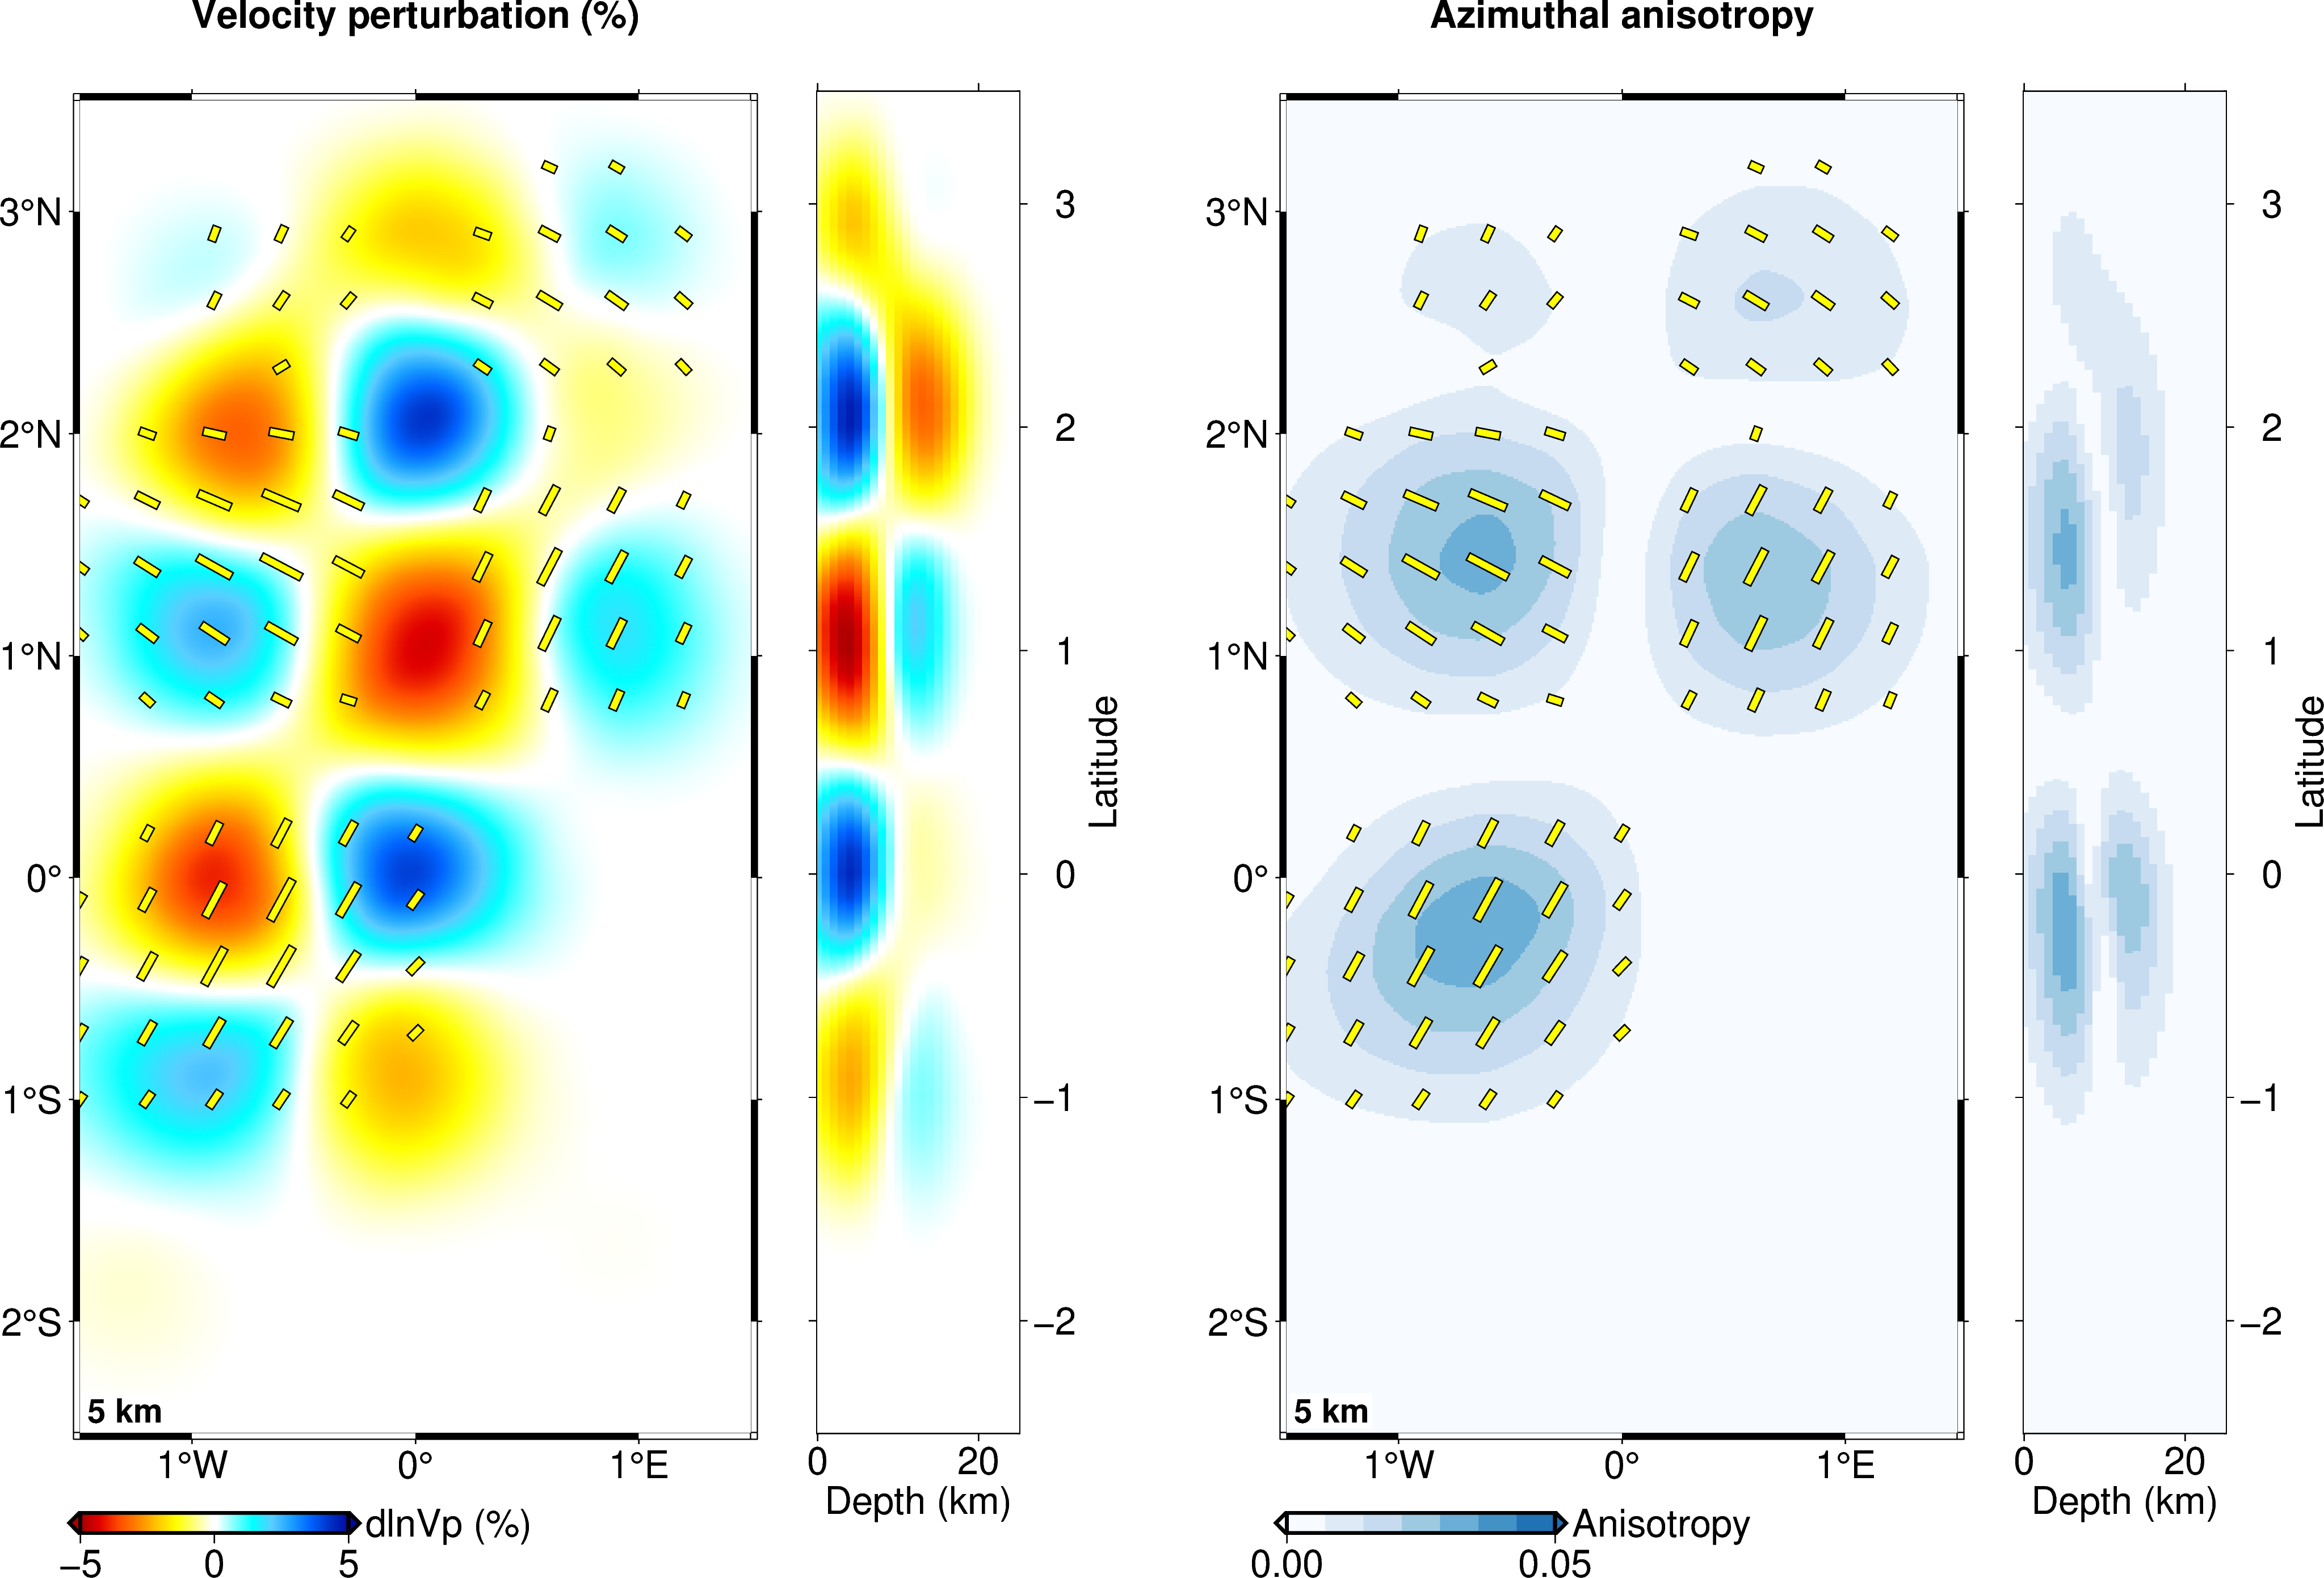

In [4]:
# 载入 PyGMT 模块
import pygmt
pygmt.config(FONT="16p")

# ---------------- read model files ----------------

# read initial and final model file
att_model = pta.ATTModel.read(init_model_file, par_file)
init_model = att_model.to_xarray()

att_model = pta.ATTModel.read(ckb_model_file, par_file)
ckb_model = att_model.to_xarray()

# interp vel at depth = 5 km
depth = 5.0
vel_init    = init_model.interp_dep(depth, field='vel')    # vel_init[i,:] are (lon, lat, vel)
vel_ckb     = ckb_model.interp_dep(depth, field='vel')    # vel_ckb[i,:] are (lon, lat, vel)

# ----------------- pygmt plot ------------------

fig = pygmt.Figure()
pygmt.makecpt(cmap="./utils/svel13_chen.cpt", series=[-5,5], background=True, reverse=False)    # colorbar


# ------------ plot horizontal profile of velocity ------------
region = [-1.5, 1.5, -2.5, 3.5]    # region of interest
fig.basemap(region=region, frame=["xa1","ya1","+tVelocity perturbation (%)"], projection="M10c")   # base map

prof_init    = init_model.interp_dep(depth, field='vel')    # prof_init[i,:] are (lon, lat, vel)
prof_ckb     = ckb_model.interp_dep(depth, field='vel')    # prof_ckb[i,:] are (lon, lat, vel)
lon = prof_init[:,0]    # longitude
lat = prof_init[:,1]    # latitude
vel_pert = (prof_ckb[:,2] - prof_init[:,2])/prof_init[:,2] * 100    # velocity perturbation related to initial model

grid = pygmt.surface(x=lon, y=lat, z=vel_pert, spacing=0.01,region=region)

fig.grdimage(grid = grid)   # plot figure
fig.text(text="%d km"%(depth), x = region[0] + 0.2 , y = region[2] + 0.1, font = "14p,Helvetica-Bold,black", fill = "white") 

# fast velocity directions (FVDs)
samp_interval = [3, 3]   # control the density of anisotropic arrows (sampling rate in lon and lat directions)
width = 0.12        # width of the anisotropic arrow
ani_per_1 = 0.005; ani_per_2 = 0.05; scale = 0.8; basic = 0.2    # control the length of anisotropic arrows related to the amplitude of anisotropy. length = 0.1 + (amplitude - ani_per_1) / (ani_per_2 - ani_per_1) * scale
ani_thd = ani_per_1 # if the amplitude of anisotropy is smaller than ani_thd, no anisotropic arrow will be plotted

phi         = ckb_model.interp_dep(depth, field='phi', samp_interval=samp_interval)          # phi_inv[i,:] are (lon, lat, phi)
epsilon     = ckb_model.interp_dep(depth, field='epsilon', samp_interval=samp_interval)      # epsilon_inv[i,:] are (lon, lat, epsilon)
ani_lon     = phi[:,0].reshape(-1,1)
ani_lat     = phi[:,1].reshape(-1,1)
ani_phi     = phi[:,2].reshape(-1,1)
length      = ((epsilon[:,2] - ani_per_1) / (ani_per_2 - ani_per_1) * scale + basic).reshape(-1,1)
ani_arrow      = np.hstack([ani_lon, ani_lat, ani_phi, length, np.ones((ani_lon.size,1))*width])   # lon, lat, color, angle[-90,90], length, width

# remove arrows with small amplitude of anisotropy
idx = np.where(epsilon[:,2] > ani_thd)[0]    # indices of arrows with large enough amplitude of anisotropy
ani_arrow = ani_arrow[idx,:]    # remove arrows with small amplitude of anisotropy

# plot anisotropic arrows
fig.plot(ani_arrow, style='j', fill='yellow1', pen='0.5p,black')    # plot fast velocity direction


# colorbar
fig.shift_origin(xshift=0, yshift=-1.5)  
fig.colorbar(frame = ["a5","y+ldlnVp (%)"], position="+e+w4c/0.3c+h") 
fig.shift_origin(xshift=0, yshift= 1.5)  

# ------------ plot horivertical profile of velocity ------------
fig.shift_origin(xshift=11, yshift= 0)  

region = [0, 25, -2.5, 3.5]    # region of interest
fig.basemap(region=region, frame=["xa20+lDepth (km)","ya1+lLatitude","nSwE"], projection="X3c/20c")   # base map

start = [0,-2.5]; end = [0,3.5]; gap = 1
prof_init    = init_model.interp_sec(start, end, field='vel', val = gap)      # prof_init[i,:] are (lon, lat, dis, dep, vel)
prof_ckb     = ckb_model.interp_sec(start, end, field='vel', val = gap)      # prof_ckb[i,:] are (lon, lat, dis, dep, vel)
lat = prof_init[:,1]    # lat
dep = prof_init[:,3]    # depth
vel = (prof_ckb[:,4] - prof_init[:,4])/prof_init[:,4] * 100    # velocity perturbation related to initial model    

grid = pygmt.surface(x=dep, y=lat, z=vel, spacing="1/0.01",region=region)

fig.grdimage(grid = grid)   # plot figure


# ------------ plot horizontal profile of anisotropy ------------

fig.shift_origin(xshift=7, yshift= 0)  

pygmt.makecpt(cmap="./utils/Blues_07_ani_mag.cpt", series=[0, 0.05], background=True, reverse=False)    # colorbar

region = [-1.5, 1.5, -2.5, 3.5]    # region of interest
fig.basemap(region=region, frame=["xa1","ya1","+tAzimuthal anisotropy"], projection="M10c")   # base map

prof_ckb     = ckb_model.interp_dep(depth, field='epsilon')    # prof_ckb[i,:] are (lon, lat, vel)
lon = prof_ckb[:,0]    # longitude
lat = prof_ckb[:,1]    # latitude
ani = prof_ckb[:,2]    # azimuthal anisotropy

grid = pygmt.surface(x=lon, y=lat, z=ani, spacing=0.01,region=region)

fig.grdimage(grid = grid)   # plot figure
fig.text(text="%d km"%(depth), x = region[0] + 0.2 , y = region[2] + 0.1, font = "14p,Helvetica-Bold,black", fill = "white") 

# plot anisotropic arrows
fig.plot(ani_arrow, style='j', fill='yellow1', pen='0.5p,black')    # plot fast velocity direction

# colorbar
fig.shift_origin(xshift=0, yshift=-1.5)  
pygmt.makecpt(cmap="./utils/Blues_07_ani_mag.cpt", series=[0, 0.05], background=True, reverse=False)    # colorbar
fig.colorbar(frame = ["a0.05","y+lAnisotropy"], position="+e+w4c/0.3c+h") 
fig.shift_origin(xshift=0, yshift= 1.5)  


# ------------ plot horivertical profile of velocity ------------
fig.shift_origin(xshift=11, yshift= 0)  

region = [0, 25, -2.5, 3.5]    # region of interest
fig.basemap(region=region, frame=["xa20+lDepth (km)","ya1+lLatitude","nSwE"], projection="X3c/20c")   # base map

start = [-0.75,-2.5]; end = [-0.75,3.5]; gap = 1
prof_ckb     = ckb_model.interp_sec(start, end, field='epsilon', val = gap)      # prof_ckb[i,:] are (lon, lat, dis, dep, vel)
lat = prof_ckb[:,1]    # lat
dep = prof_ckb[:,3]    # depth
ani = prof_ckb[:,4]    # azimuthal anisotropy

grid = pygmt.surface(x=dep, y=lat, z=ani, spacing="1/0.01",region=region)

fig.grdimage(grid = grid)   # plot figure

fig.savefig(f"figs/{output_fname}")  # save figure
fig.show()
